# 03. MLP con PINN como función de Pérdida

## 1. Introducción

Las redes neuronales son un tipo de modelo muy potente para aprender sobre un 
dataset. Sin embargo, solamente aprenden de los propios datos y son muy
codiciosas, es decir, necesitan de una cantidad sustancial de los mismos para 
dar buenos resultados.

No obstante, existe una solución a esa problemática, que concretamente afecta
al dataset de este proyecto al ser tan pequeño. Las PINNs (Physical Informed
Neural Networks), al contrario de las NN convencionales, incluyen en la función 
de pérdida términos asociados a ecuaciones que describen fenómenos físicos. 
Dichas restricciones, conectan la red neuronal con la realidad para que,
mientras se sigue aprendiendo de los datos, se impide que se aprendan patrones
que sean imposibles en la realidad.

## 2. Implementación

Primeramente se importan los módulos necesarios para la realización de esta
etapa.

In [4]:
# Se recarga el paquete src
%load_ext autoreload
%autoreload 2

# Se importan los paquetes externos necesarios
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
import torch.optim as optim
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt



# Se importan los módulos internos del paquete src
from src.dataset.dataset import RadiationDataset
from src.learning.models import PINNEmbrittlement, pinn_loss

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Después se carga el Dataset y se preprocesa.

In [5]:
# 1. Se instancia el Dataset personalizado
csv_path = '../data/df_plotter_cm2.csv'
dataset = RadiationDataset(csv_path)

# 2. Se dividen los datos en conjuntos de entrenamiento y prueba
train_set, _, test_set = dataset.data_split(test_factor=0.2)

# 3. Preprocesamiento: Se entrena el escalador con el conjunto de entrenamiento 
#    y se aplica a todo el dataset
dataset.preprocess(train_set, preprocessor=StandardScaler())

# 4. Se crean los DataLoaders de PyTorch a partir de los Subsets generados
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

print(f"Datos preparados: Train={len(train_set)}, Test={len(test_set)}")

Datos preparados: Train=1511, Test=378


Se crea objeto de la red neuronal y se aplican hiperparámetros generales, luego se entrena

In [ ]:
# 1. Definición de Hiperparámetros
HP_HIDDEN_DIM = 64
HP_NUM_LAYERS = 3
HP_ACTIVATION = nn.SiLU 
HP_LEARNING_RATE = 0.001
HP_EPOCHS = 300
HP_LAMBDA_DATA = 1.0
HP_LAMBDA_MONO = 0.5

# 2. Configuración del dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilizando dispositivo: {device}")

# 3. Instancia de la PINN con hiperparámetros variables
input_dim = 7 
modelo_pinn = PINNEmbrittlement(
    input_dim=input_dim, 
    hidden_dim=HP_HIDDEN_DIM, 
    num_layers=HP_NUM_LAYERS,
    activation=HP_ACTIVATION,
    preprocessor=dataset.preprocessor
).to(device)

optimizer = optim.Adam(modelo_pinn.parameters(), lr=HP_LEARNING_RATE)

# 4. Bucle de Entrenamiento
print("Iniciando entrenamiento...")
modelo_pinn.train()

for epoch in range(HP_EPOCHS):
    epoch_loss_data = 0.0
    epoch_loss_mono = 0.0
    
    for batch in train_loader:
        batch = batch.to(device)
        target_idx = 6
        
        X_batch = torch.cat([batch[:, :target_idx], batch[:, target_idx+1:]], dim=1)
        y_batch = batch[:, target_idx].view(-1, 1)
        
        X_batch.requires_grad_(True)
        optimizer.zero_grad()
        
        # Pasamos los lambdas a la función de pérdida
        loss, loss_data, loss_mono = pinn_loss(
            modelo_pinn, X_batch, y_batch, 
            fluence_idx=6, 
            lambda_data=HP_LAMBDA_DATA, 
            lambda_mono=HP_LAMBDA_MONO
        )
        
        loss.backward()
        optimizer.step()
        
        epoch_loss_data += loss_data.item()
        epoch_loss_mono += loss_mono.item()
        
    if (epoch+1) % 50 == 0:
        avg_loss_data = epoch_loss_data / len(train_loader)
        avg_loss_mono = epoch_loss_mono / len(train_loader)
        print(f"Epoch {epoch+1:03d}/{HP_EPOCHS} | Loss NN: {avg_loss_data:.4f} | Loss PINN: {avg_loss_mono:.4f}")

print("Entrenamiento finalizado.")

Utilizando dispositivo: cuda
Iniciando entrenamiento...
Epoch 050/300 | Loss NN: 0.1247 | Loss PINN: 0.0000
Epoch 100/300 | Loss NN: 0.1075 | Loss PINN: 0.0000
Epoch 150/300 | Loss NN: 0.0999 | Loss PINN: 0.0000
Epoch 200/300 | Loss NN: 0.0926 | Loss PINN: 0.0000
Epoch 250/300 | Loss NN: 0.0859 | Loss PINN: 0.0000
Epoch 300/300 | Loss NN: 0.0805 | Loss PINN: 0.0000
Entrenamiento finalizado.


Se evalua la PINN entrenada

In [ ]:
# 1. Modo evaluación
modelo_pinn.eval()

y_true_scaled = []
y_pred_scaled = []

# 2. Generar predicciones
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        target_idx = 6
        X_batch = torch.cat([batch[:, :target_idx], batch[:, target_idx+1:]], dim=1)
        y_batch = batch[:, target_idx].view(-1, 1)
        
        preds = modelo_pinn(X_batch)
        y_pred_scaled.append(preds.cpu().numpy())
        y_true_scaled.append(y_batch.cpu().numpy())

y_true_scaled = np.vstack(y_true_scaled)
y_pred_scaled = np.vstack(y_pred_scaled)

# 3. Desescalado
num_columns = 8
dummy_true = np.zeros((len(y_true_scaled), num_columns))
dummy_pred = np.zeros((len(y_pred_scaled), num_columns))

dummy_true[:, target_idx] = y_true_scaled.flatten()
dummy_pred[:, target_idx] = y_pred_scaled.flatten()

y_true_unscaled = dataset.preprocessor.inverse_transform(dummy_true)[:, target_idx]
y_pred_unscaled = dataset.preprocessor.inverse_transform(dummy_pred)[:, target_idx]

# 4. Cálculo de métricas
r2 = r2_score(y_true_unscaled, y_pred_unscaled)
rmse = np.sqrt(mean_squared_error(y_true_unscaled, y_pred_unscaled))

print(f"Métricas de Test -> R²: {r2:.3f} | RMSE: {rmse:.3f} °C")

Métricas de Test -> R²: 0.869 | RMSE: 13.080 °C
Métricas de Test -> R²: 0.869 | RMSE: 13.080 °C


Se grafican los resultados en un plot

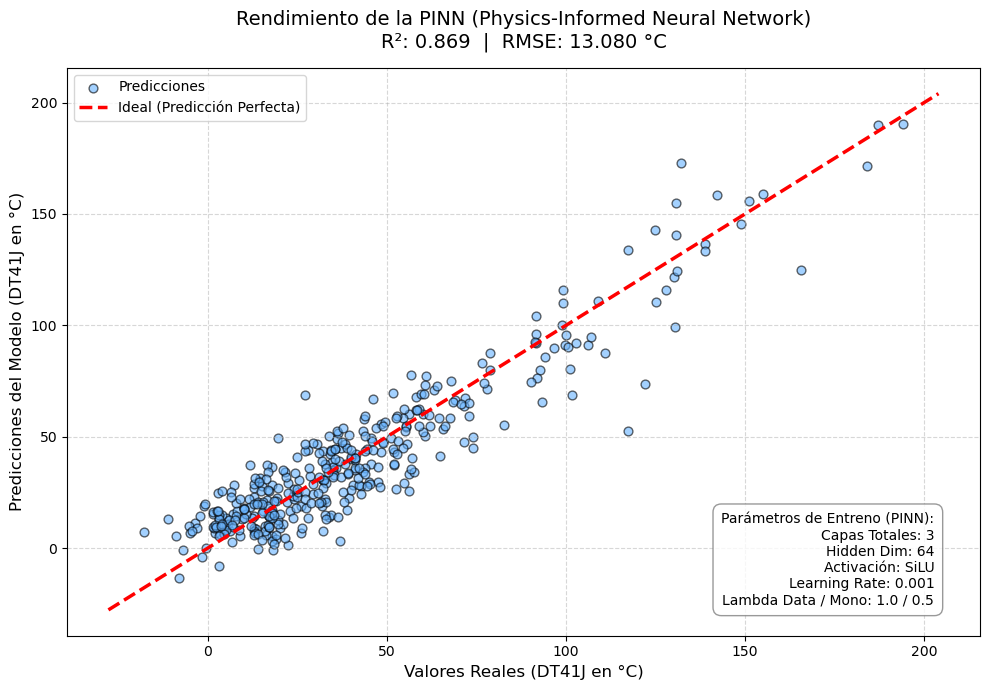

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))

# Dispersión
ax.scatter(y_true_unscaled, y_pred_unscaled, 
           alpha=0.6, edgecolors='k', color='#66b3ff', s=40, label='Predicciones')

# Línea Ideal
min_val = min(y_true_unscaled.min(), y_pred_unscaled.min()) - 10
max_val = max(y_true_unscaled.max(), y_pred_unscaled.max()) + 10
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2.5, label='Ideal (Predicción Perfecta)')

# Textos
ax.set_xlabel('Valores Reales (DT41J en °C)', fontsize=12)
ax.set_ylabel('Predicciones del Modelo (DT41J en °C)', fontsize=12)
ax.set_title(f'Rendimiento de la PINN (Physics-Informed Neural Network)\nR²: {r2:.3f}  |  RMSE: {rmse:.3f} °C', 
             fontsize=14, pad=15)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper left', fontsize=10)

# Caja de texto que lee las variables de hiperparámetros automáticamente
activation_name = HP_ACTIVATION.__name__ if hasattr(HP_ACTIVATION, '__name__') else str(HP_ACTIVATION)

textstr = '\n'.join((
    r'Parámetros de Entreno (PINN):',
    f'Capas Totales: {HP_NUM_LAYERS}',
    f'Hidden Dim: {HP_HIDDEN_DIM}',
    f'Activación: {activation_name}',
    f'Learning Rate: {HP_LEARNING_RATE}',
    f'Lambda Data / Mono: {HP_LAMBDA_DATA} / {HP_LAMBDA_MONO}'
))

props = dict(boxstyle='round,pad=0.6', facecolor='white', edgecolor='gray', alpha=0.8)
ax.text(0.95, 0.05, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.show()